In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("healthcare_dataset.csv")

In [5]:
# View Data

In [10]:
print(df.head())
print(df.info())
print(df.shape)

   Patient_ID  Age  Gender  Blood_Pressure  Heart_Rate  Cholesterol_Level  \
0           1   51  Female              97          90                282   
1           2   92   Other             129          80                169   
2           3   14    Male             172          76                157   
3           4   71  Female             131          82                150   
4           5   60    Male             130          96                206   

    BMI                Diagnosis Treatment_Plan Follow_Up_Date  
0  35.2             Hypertension    Observation     2024-01-01  
1  32.3                  Healthy     Medication     2024-01-02  
2  29.9                 Diabetes    Observation     2024-01-03  
3  19.4  Coronary Artery Disease        Surgery     2024-01-04  
4  39.3                 Diabetes            NaN     2024-01-05  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dt

In [7]:
# Checking Missing Values

In [11]:
print(df.isnull().sum())

Patient_ID            0
Age                   0
Gender                0
Blood_Pressure        0
Heart_Rate            0
Cholesterol_Level     0
BMI                   0
Diagnosis             0
Treatment_Plan       95
Follow_Up_Date        0
dtype: int64


In [12]:
df['Treatment_Plan'] = df['Treatment_Plan'].fillna('Unknown')

In [10]:
print(df.isnull().sum())

Patient_ID           0
Age                  0
Gender               0
Blood_Pressure       0
Heart_Rate           0
Cholesterol_Level    0
BMI                  0
Diagnosis            0
Treatment_Plan       0
Follow_Up_Date       0
dtype: int64


In [13]:
# Removing Duplicates

In [14]:
print("Before:", df.shape)


Before: (500, 10)


In [14]:
df = df.drop_duplicates()

In [15]:
print("After:", df.shape)

After: (500, 10)


In [16]:
# Fix Data Types

In [17]:
df["Follow_Up_Date"] = pd.to_datetime(df["Follow_Up_Date"], errors = "coerce" )

In [18]:
df["Follow_Up_Date"]

0     2024-01-01
1     2024-01-02
2     2024-01-03
3     2024-01-04
4     2024-01-05
         ...    
495   2025-05-10
496   2025-05-11
497   2025-05-12
498   2025-05-13
499   2025-05-14
Name: Follow_Up_Date, Length: 500, dtype: datetime64[ns]

In [19]:
# Handling Missing Values
# Numeric Columns
# Categorical Columns

In [20]:
numeric_cols = ['Age', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
df[numeric_cols].isnull().sum()

Age                  0
Blood_Pressure       0
Heart_Rate           0
Cholesterol_Level    0
BMI                  0
dtype: int64

In [22]:
categorical_cols = [
    'Gender',
    'Diagnosis',
    'Treatment_Plan'
    
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [23]:
df[categorical_cols].isnull().sum()

Gender            0
Diagnosis         0
Treatment_Plan    0
dtype: int64

In [33]:
# Check Invalid Values

In [34]:
df = df[df["Age"] > 0]

In [24]:
df

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,Unknown,2024-01-05
...,...,...,...,...,...,...,...,...,...,...
495,496,62,Other,151,88,222,27.6,Healthy,Medication,2025-05-10
496,497,68,Other,169,69,198,27.3,Healthy,Lifestyle Changes,2025-05-11
497,498,21,Female,177,71,185,38.0,Hypertension,Observation,2025-05-12
498,499,92,Female,172,89,275,33.9,Hypertension,Medication,2025-05-13


In [36]:
df = df[df["BMI"] > 10]

In [37]:
df

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,Unknown,2024-01-05
...,...,...,...,...,...,...,...,...,...,...
495,496,62,Other,151,88,222,27.6,Healthy,Medication,2025-05-10
496,497,68,Other,169,69,198,27.3,Healthy,Lifestyle Changes,2025-05-11
497,498,21,Female,177,71,185,38.0,Hypertension,Observation,2025-05-12
498,499,92,Female,172,89,275,33.9,Hypertension,Medication,2025-05-13


In [38]:
# Diagnosis Count

In [25]:
print(df['Diagnosis'].value_counts())

Diagnosis
Healthy                    104
Hypertension               101
Coronary Artery Disease    101
Hyperlipidemia             101
Diabetes                    93
Name: count, dtype: int64


In [40]:
# Average Cholestrol

In [26]:
print(df['Cholesterol_Level'].mean())

225.806


In [27]:
# Blood Pressure Count

In [48]:
print(df['Blood_Pressure'].value_counts())

Blood_Pressure
140    13
129    12
115    11
118    11
151    10
       ..
117     1
166     1
137     1
147     1
169     1
Name: count, Length: 90, dtype: int64


In [28]:
# Gender Distribution

In [29]:
print(df['Gender'].value_counts())

Gender
Male      187
Female    161
Other     152
Name: count, dtype: int64


In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient_ID         491 non-null    int64         
 1   Age                491 non-null    int64         
 2   Gender             491 non-null    object        
 3   Blood_Pressure     491 non-null    int64         
 4   Heart_Rate         491 non-null    int64         
 5   Cholesterol_Level  491 non-null    int64         
 6   BMI                491 non-null    float64       
 7   Diagnosis          491 non-null    object        
 8   Treatment_Plan     491 non-null    object        
 9   Follow_Up_Date     491 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 42.2+ KB
None


In [1]:
# df.to_csv("cleaned_healthcare_dataset.csv", index = False)

In [2]:
# Histograms

In [3]:
# Histogram for Age Distribution

In [30]:
import matplotlib.pyplot as plt

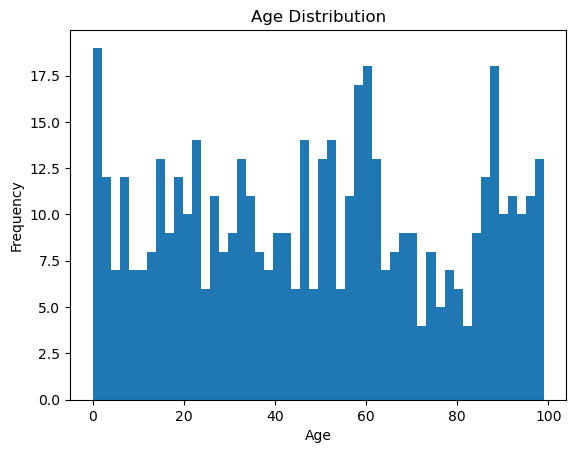

In [36]:
plt.hist(df['Age'], bins = 50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

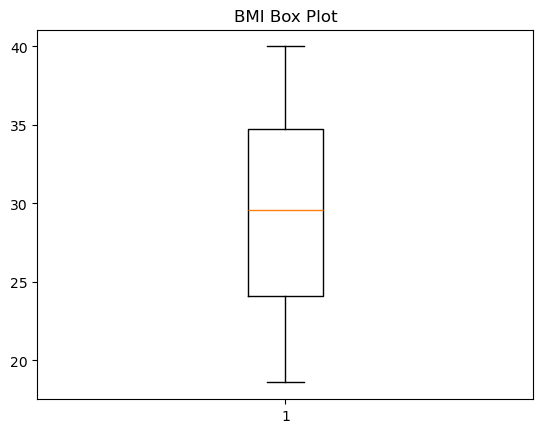

In [37]:
plt.boxplot(df['BMI'])
plt.title('BMI Box Plot')
plt.show()

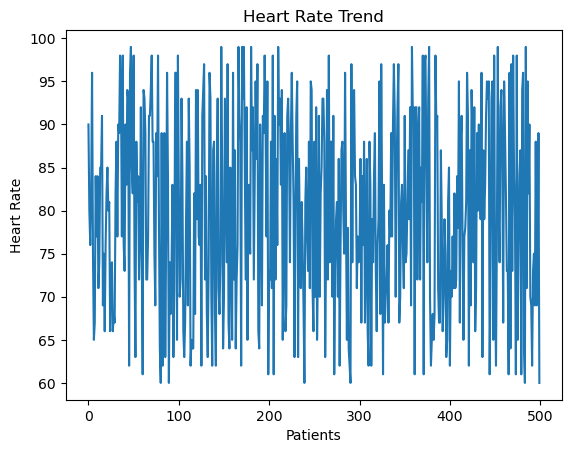

In [38]:
plt.plot(df['Heart_Rate'])

plt.title('Heart Rate Trend')
plt.xlabel('Patients')
plt.ylabel('Heart Rate')

plt.show()

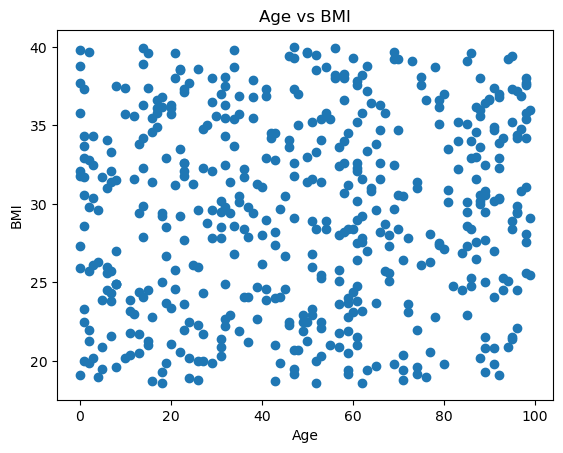

In [39]:
plt.scatter(df['Age'],df['BMI'])
plt.title('Age vs BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

In [40]:
# Conclusions

# 1. Patient Distribution

# Male patients are slightly higher compared to female and other categories.
# Most patients belong to middle - age groups

# 2. BMI Analysis

# Several patients have high BMI values,indicating overweight or obesity trends.
# BMI distribution shows possible lifestyle - related health risks

# 3. Blood Pressure Findings

# Some patients have elevated blood pressure levels.
# High BP cases may indicate hypertension risk among patients.

# 4. Heart Rate Analysis

# Most heart rate values fall within normal range.
# A few outliers were identified using box plots.


# 5. Cholestrol Analysis

# Cholestrol levels vary significantly among patients.
# Higher cholestrol values may increase cardiovascular disease risk.

# 6. Correlation Insights

# Scatter plots indicate a possible relationship between:
    
#  *Age and Blood Pressure
#  *BMI and Cholestrol Level
#  *High risks tend to increase with age and BMI


# 7. Outlier Detection

# * Box plots identified abnormal values in:
      # BMI
      # BLOOD PRESSURE
      # Billing/Health metrics
# * These outliers may require further medical attention



In [41]:
df.to_csv("cleaned_healthcare_EDA project.csv", index = False)